**Run Sim files before using the Notebook!** \
This Notebook constructs the plots related to the infidelity and the gamma overhead after the csv. files are constructed by the simulation files inside thesis/sim

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, pathlib

repo_root = pathlib.Path.cwd()

repo_root = repo_root.parent.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: /Users/fabian/qecsim


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np

**Overhead-Factor/ Physical Error Probability**

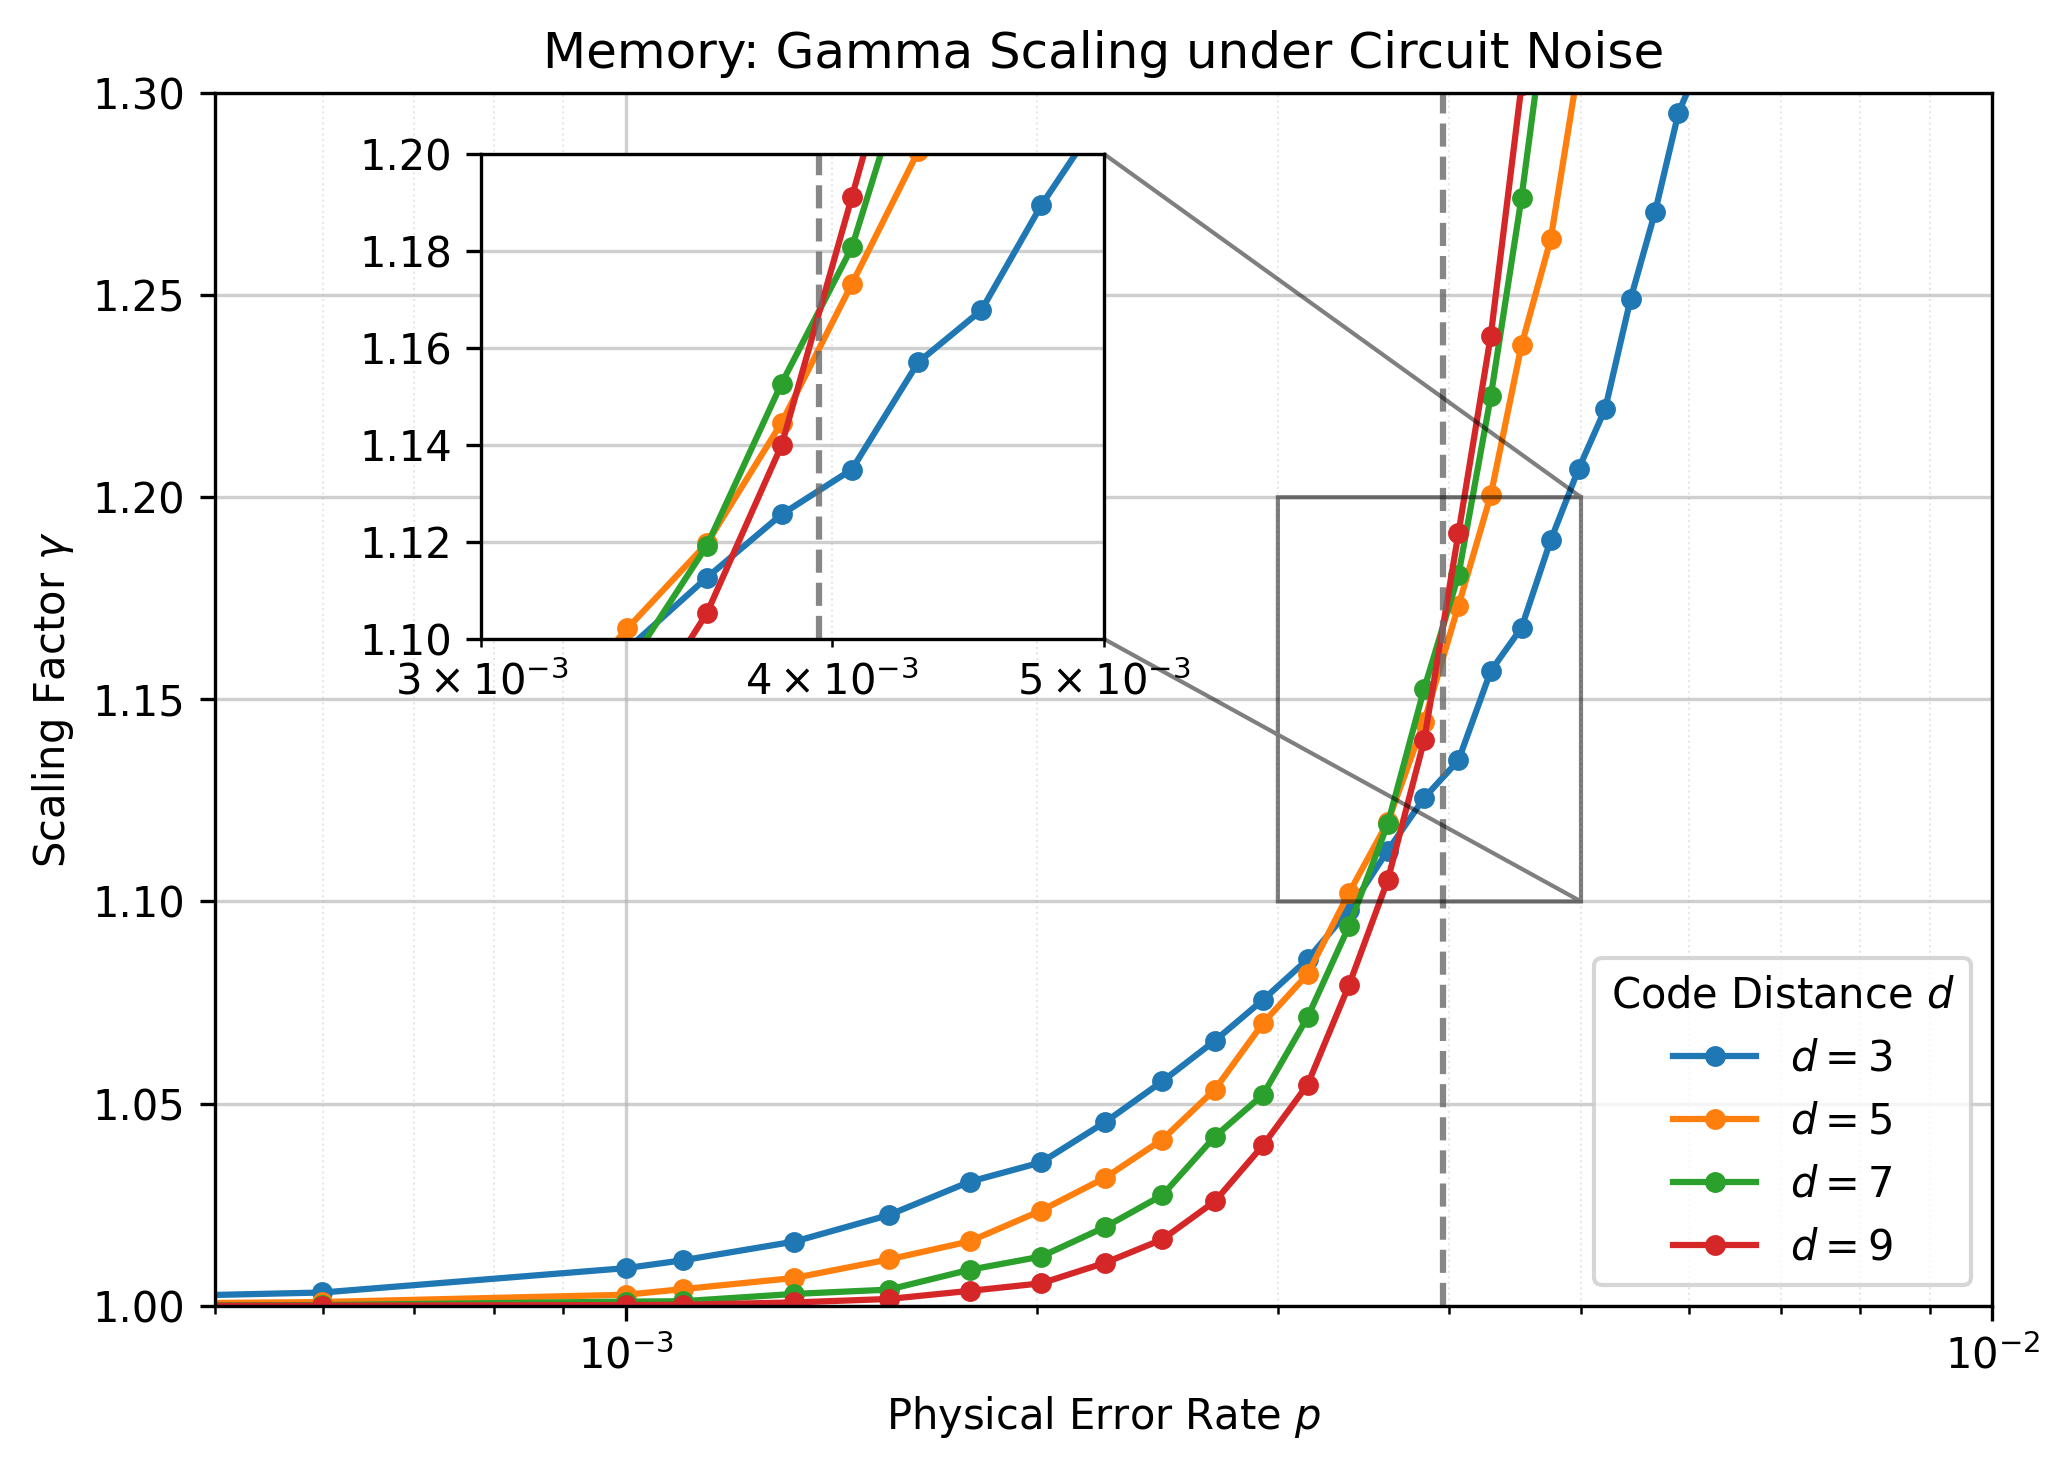

In [4]:
# Define the threshold
THRESHOLD_P = 3.96e-3

# 1. Load the data
df = pd.read_csv('../data/gamma_memory.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 1.3)
ax.set_xlim(5e-4, 1e-2)
ax.set_xscale('log') 
ax.set_title("Memory: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend kept in the lower right
ax.legend(title="Code Distance $d$", loc='lower right')

# ==========================================
# 4. Inset Plot for the Threshold Zoom
# ==========================================
# Placed in the upper left [x0, y0, width, height]
# x starts at 5% from the left, y starts at 55% from the bottom
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the data onto the inset axes
for distance, group in df.groupby('distance'):
    axins.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4
    )

# Formatting the inset
axins.set_xscale('log')

# Zoomed limits for x (around p = 4e-3)
axins.set_xlim(3e-3, 5e-3)

# Note: You may need to tweak this y-limit slightly depending on 
# the exact gamma values near the threshold crossing.
axins.set_ylim(1.1, 1.2) 

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")
# ==========================================

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_memory_d3579.pdf", bbox_inches='tight')

plt.show()

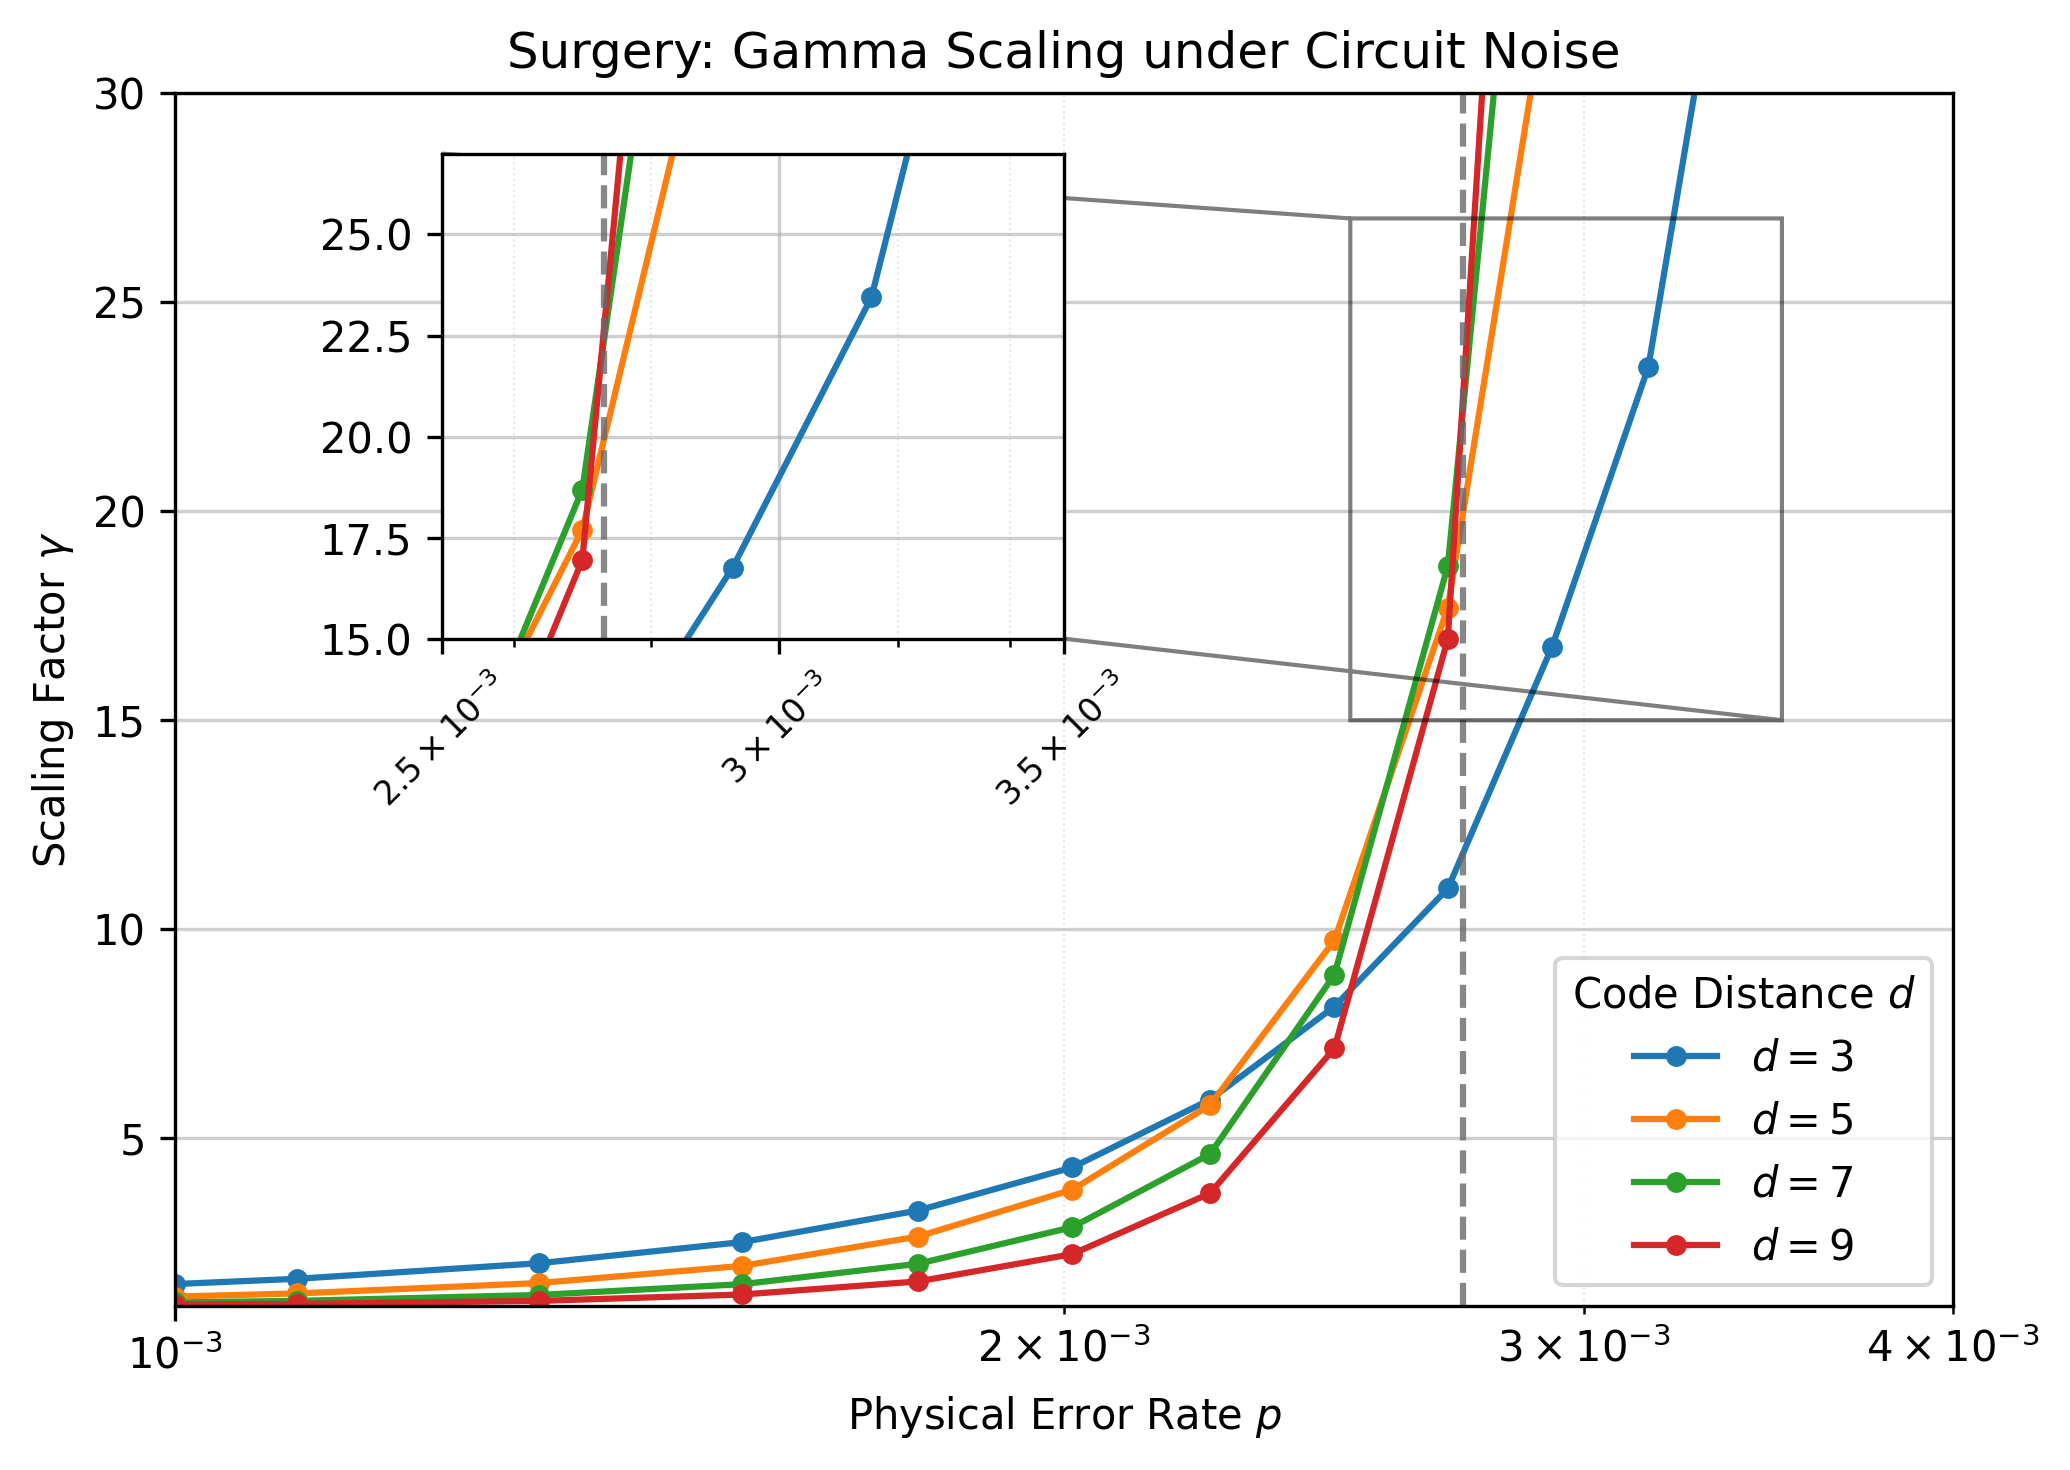

In [ ]:
# Define the threshold
THRESHOLD_P = 2.73e-3

# 1. Load the data
df = pd.read_csv('../data/gamma_surgery.csv')

# 2. Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for distance, group in df.groupby('distance'):
    ax.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4,
        label=r"$d={}$".format(distance)
    )

# 3. Main Axis Formatting
ax.set_ylim(1.0, 30.0)
ax.set_xlim(1e-3, 4e-3)
ax.set_xscale('log') 
ax.set_title("Surgery: Gamma Scaling under Circuit Noise")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel(r"Scaling Factor $\gamma$")

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend placed in the lower right
ax.legend(title="Code Distance $d$", loc='lower right')

# ==========================================
# 4. Inset Plot for the Threshold Zoom
# ==========================================
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the data onto the inset axes
for distance, group in df.groupby('distance'):
    axins.plot(
        group['physical_error_probability'], 
        group['gamma'], 
        marker='o', 
        markersize=4
    )

# Formatting the inset
axins.set_xscale('log')

# Zoomed limits for x (around p = 2.73e-3)
axins.set_xlim(2.5e-3, 3.5e-3)
axins.set_ylim(15.0, 27.0) 

axins.set_xticks([2.5e-3, 3.0e-3, 3.5e-3])
def sci_format(x, pos):
    # This takes the number, divides by 1e-3, and formats it nicely into a LaTeX string
    return f"${x / 1e-3:g} \\times 10^{{-3}}$"

axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())

# 3. Rotate the labels 45 degrees and slightly reduce font size to ensure they fit
axins.tick_params(axis='x', rotation=45, labelsize=8)
# ----------------------------------------------

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")
# ==========================================

# 5. Final output
fig.set_dpi(300)
plt.tight_layout()

# Save as PDF
plt.savefig("../plots/gamma_surgery_d3579.pdf", bbox_inches='tight')

plt.show()

In [6]:
# Calculate the infidelities around the threshold for the d=7,9 memory cases

# Load the matrices for d=3,5,7,9
ptm_d3_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d3_CircuitNoise.npy")
ptm_d5_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d7_CircuitNoise.npy")
ptm_d9_ideal = np.load("../data/ptm_matrices_memory/ptm_ideal_d9_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
probs = np.concatenate([
    np.geomspace(1e-5, 1e-3, 10),
    np.linspace(1.1e-3, 1e-2, 40),
])
ptm_d3_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d3_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d9_noisy = [np.load(f"../data/ptm_matrices_memory/ptm_noisy_d9_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 4
    return 1 - fidelity

# Calculate infidelities for d=3,5,7,9
infidelities_d3 = [calculate_infidelity(ptm_d3_ideal, ptm_noisy) for ptm_noisy in ptm_d3_noisy]
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]
infidelities_d9 = [calculate_infidelity(ptm_d9_ideal, ptm_noisy) for ptm_noisy in ptm_d9_noisy]

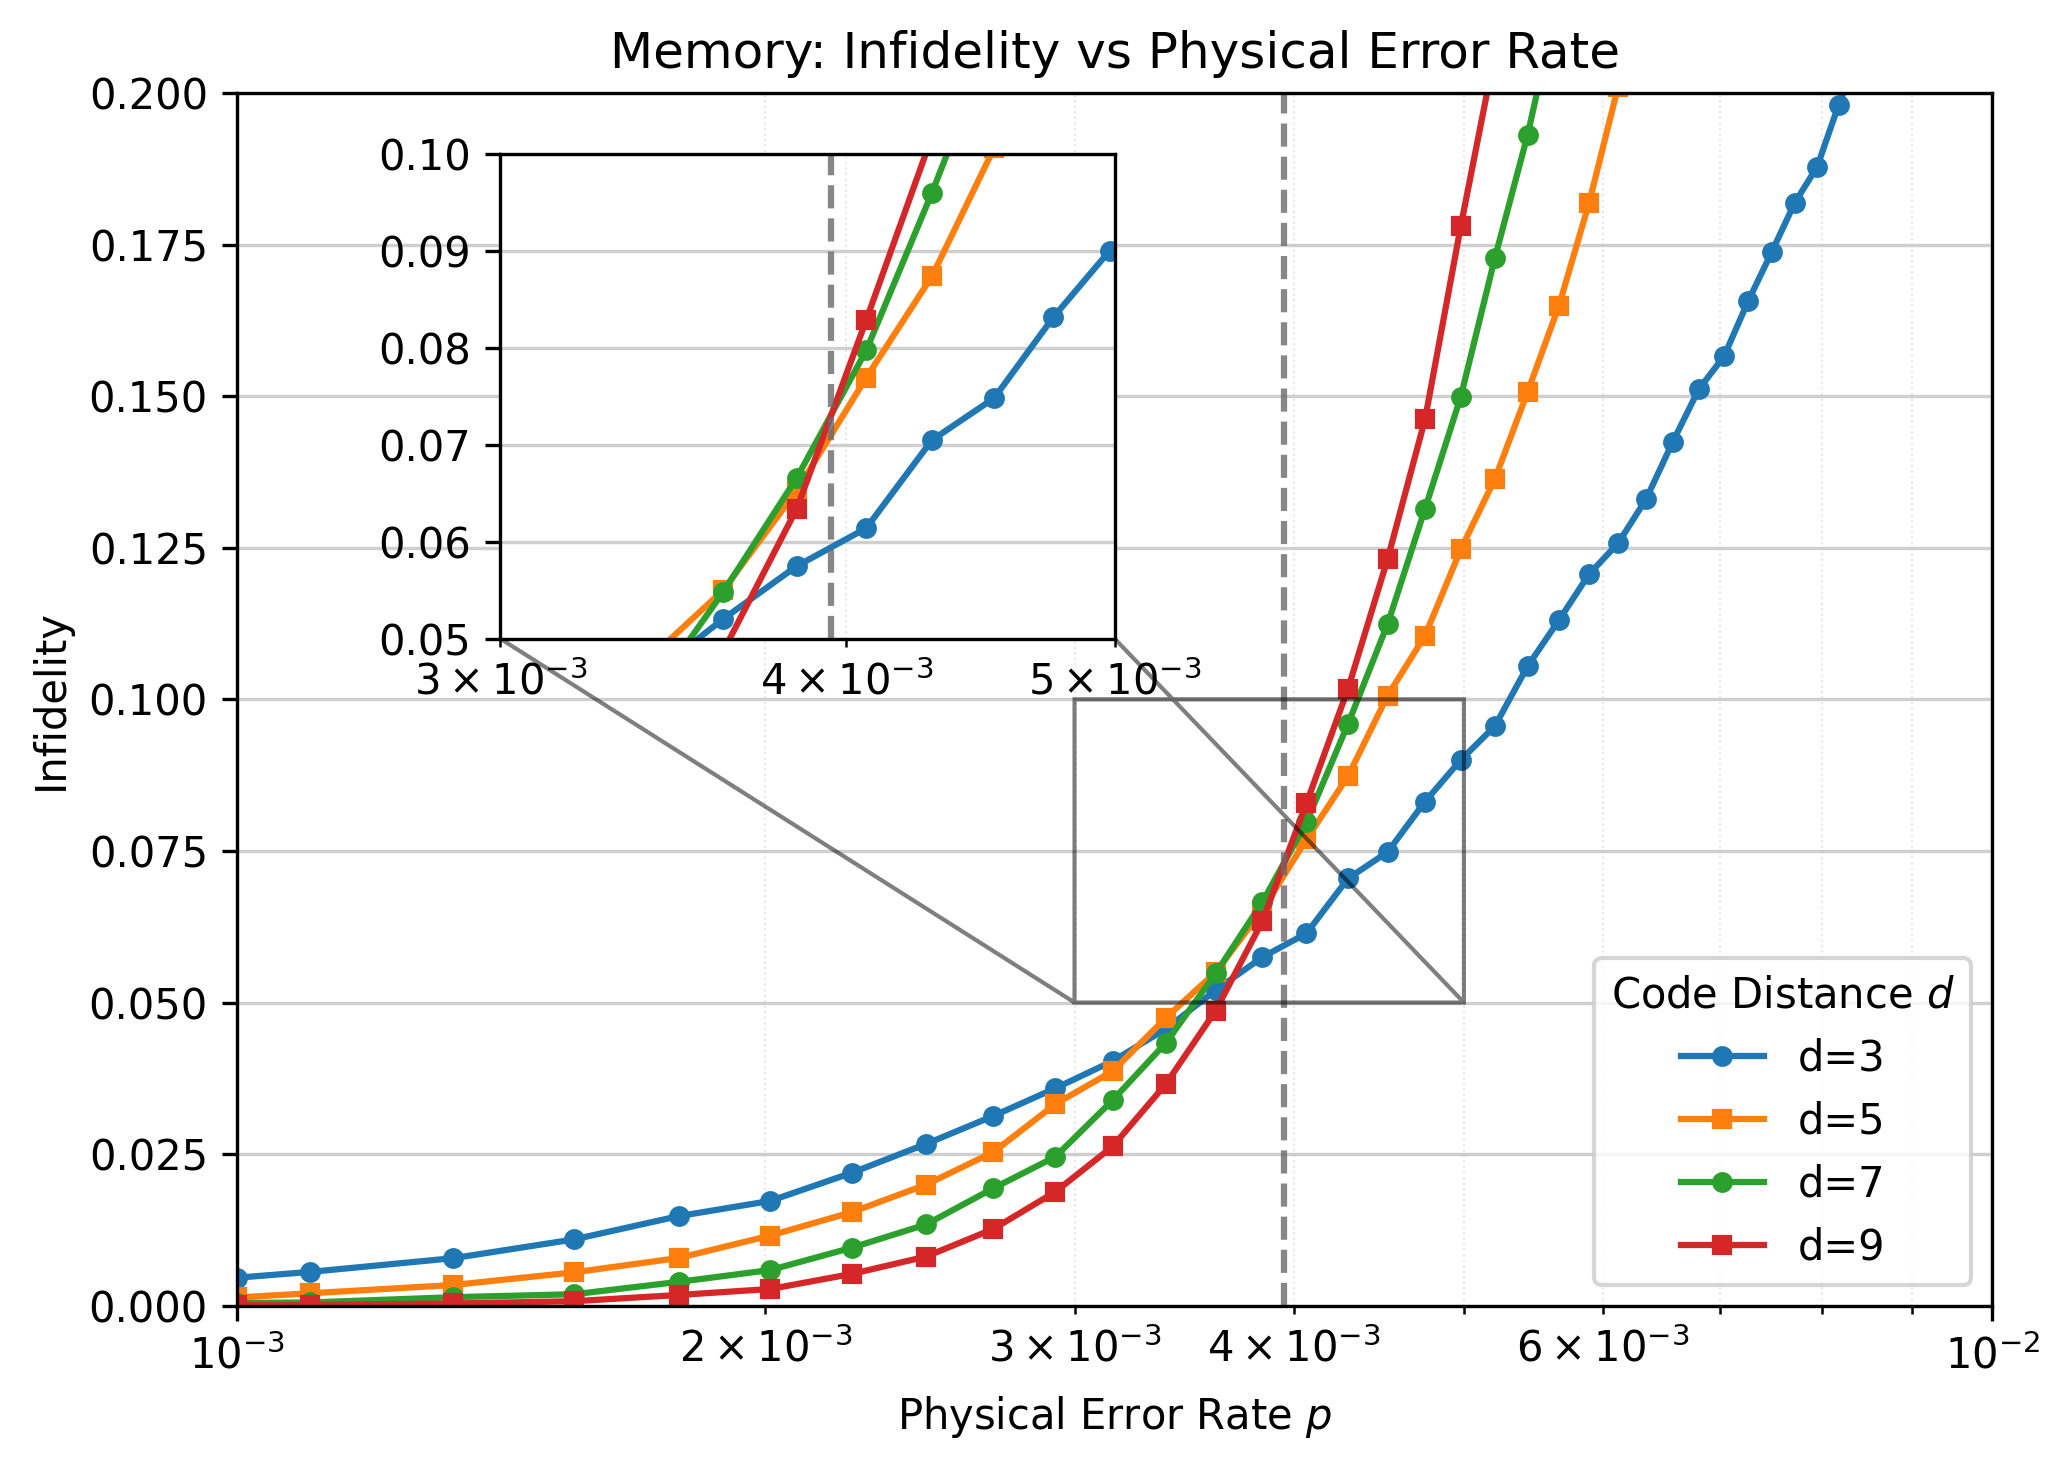

In [ ]:
# Define the threshold
THRESHOLD_P = 3.95e-3

# Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Plot on the main axis
ax.plot(probs, infidelities_d3, 'o-', markersize=4, label='d=3')
ax.plot(probs, infidelities_d5, 's-', markersize=4, label='d=5')
ax.plot(probs, infidelities_d7, 'o-', markersize=4, label='d=7')
ax.plot(probs, infidelities_d9, 's-', markersize=4, label='d=9')

# Main Axis Formatting
ax.set_ylim(0, 0.2)
ax.set_xlim(1e-3, 1e-2)
ax.set_xscale('log')
ax.set_title('Memory: Infidelity vs Physical Error Rate')
ax.set_xlabel('Physical Error Rate $p$')
ax.set_ylabel('Infidelity')

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend placed in the lower right
ax.legend(title="Code Distance $d$", loc='lower right')

# ==========================================
# Inset Plot for the Threshold Zoom
# ==========================================
# Placed in the upper left [x0, y0, width, height]
axins = ax.inset_axes([0.15, 0.55, 0.35, 0.4])

# Re-plot the exact same lines onto the inset axes
axins.plot(probs, infidelities_d3, 'o-', markersize=4)
axins.plot(probs, infidelities_d5, 's-', markersize=4)
axins.plot(probs, infidelities_d7, 'o-', markersize=4)
axins.plot(probs, infidelities_d9, 's-', markersize=4)

# Formatting the inset
axins.set_xscale('log')

# Zoomed limits for x (around p = 4e-3)
axins.set_xlim(3e-3, 5e-3)
axins.set_ylim(0.05, 0.1) 

# 3. Rotate labels so the wider math-text labels don't crash into each other
axins.tick_params(axis='x', rotation=45, labelsize=8)
# ----------------------------------------------

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")
# ==========================================

# Final output
fig.set_dpi(300)
plt.tight_layout()

# Save plot as PDF
plt.savefig("../plots/Memory_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()

In [18]:
# Calculate the infidelities around the threshold for the d=7,9 memory cases

# Load the matrices for d=3,5,7,9
ptm_d3_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d3_CircuitNoise.npy")
ptm_d5_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d5_CircuitNoise.npy")
ptm_d7_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d7_CircuitNoise.npy")
ptm_d9_ideal = np.load("../data/ptm_matrices_surgery/ptm_ideal_d9_CircuitNoise.npy")

# Load Noisy PTMs around 7e-3
ps = np.concatenate([
    np.geomspace(1e-5, 1e-3, 10),
    np.linspace(1.1e-3, 1e-2, 40),
])
ptm_d3_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d3_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d5_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d5_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d7_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d7_p{p:.2e}_CircuitNoise.npy") for p in probs]
ptm_d9_noisy = [np.load(f"../data/ptm_matrices_surgery/ptm_noisy_d9_p{p:.2e}_CircuitNoise.npy") for p in probs]

def calculate_infidelity(ptm_ideal, ptm_noisy):
    # Ensure the first element is 1 for both matrices
    ptm_ideal = ptm_ideal.copy()
    ptm_noisy = ptm_noisy.copy()
    ptm_ideal[0, 0] = 1
    ptm_noisy[0, 0] = 1


    fidelity = np.trace(ptm_ideal.T @ ptm_noisy) / 16
    return 1 - fidelity

# Calculate infidelities for d=3,5,7,9
infidelities_d3 = [calculate_infidelity(ptm_d3_ideal, ptm_noisy) for ptm_noisy in ptm_d3_noisy]
infidelities_d5 = [calculate_infidelity(ptm_d5_ideal, ptm_noisy) for ptm_noisy in ptm_d5_noisy]
infidelities_d7 = [calculate_infidelity(ptm_d7_ideal, ptm_noisy) for ptm_noisy in ptm_d7_noisy]
infidelities_d9 = [calculate_infidelity(ptm_d9_ideal, ptm_noisy) for ptm_noisy in ptm_d9_noisy]

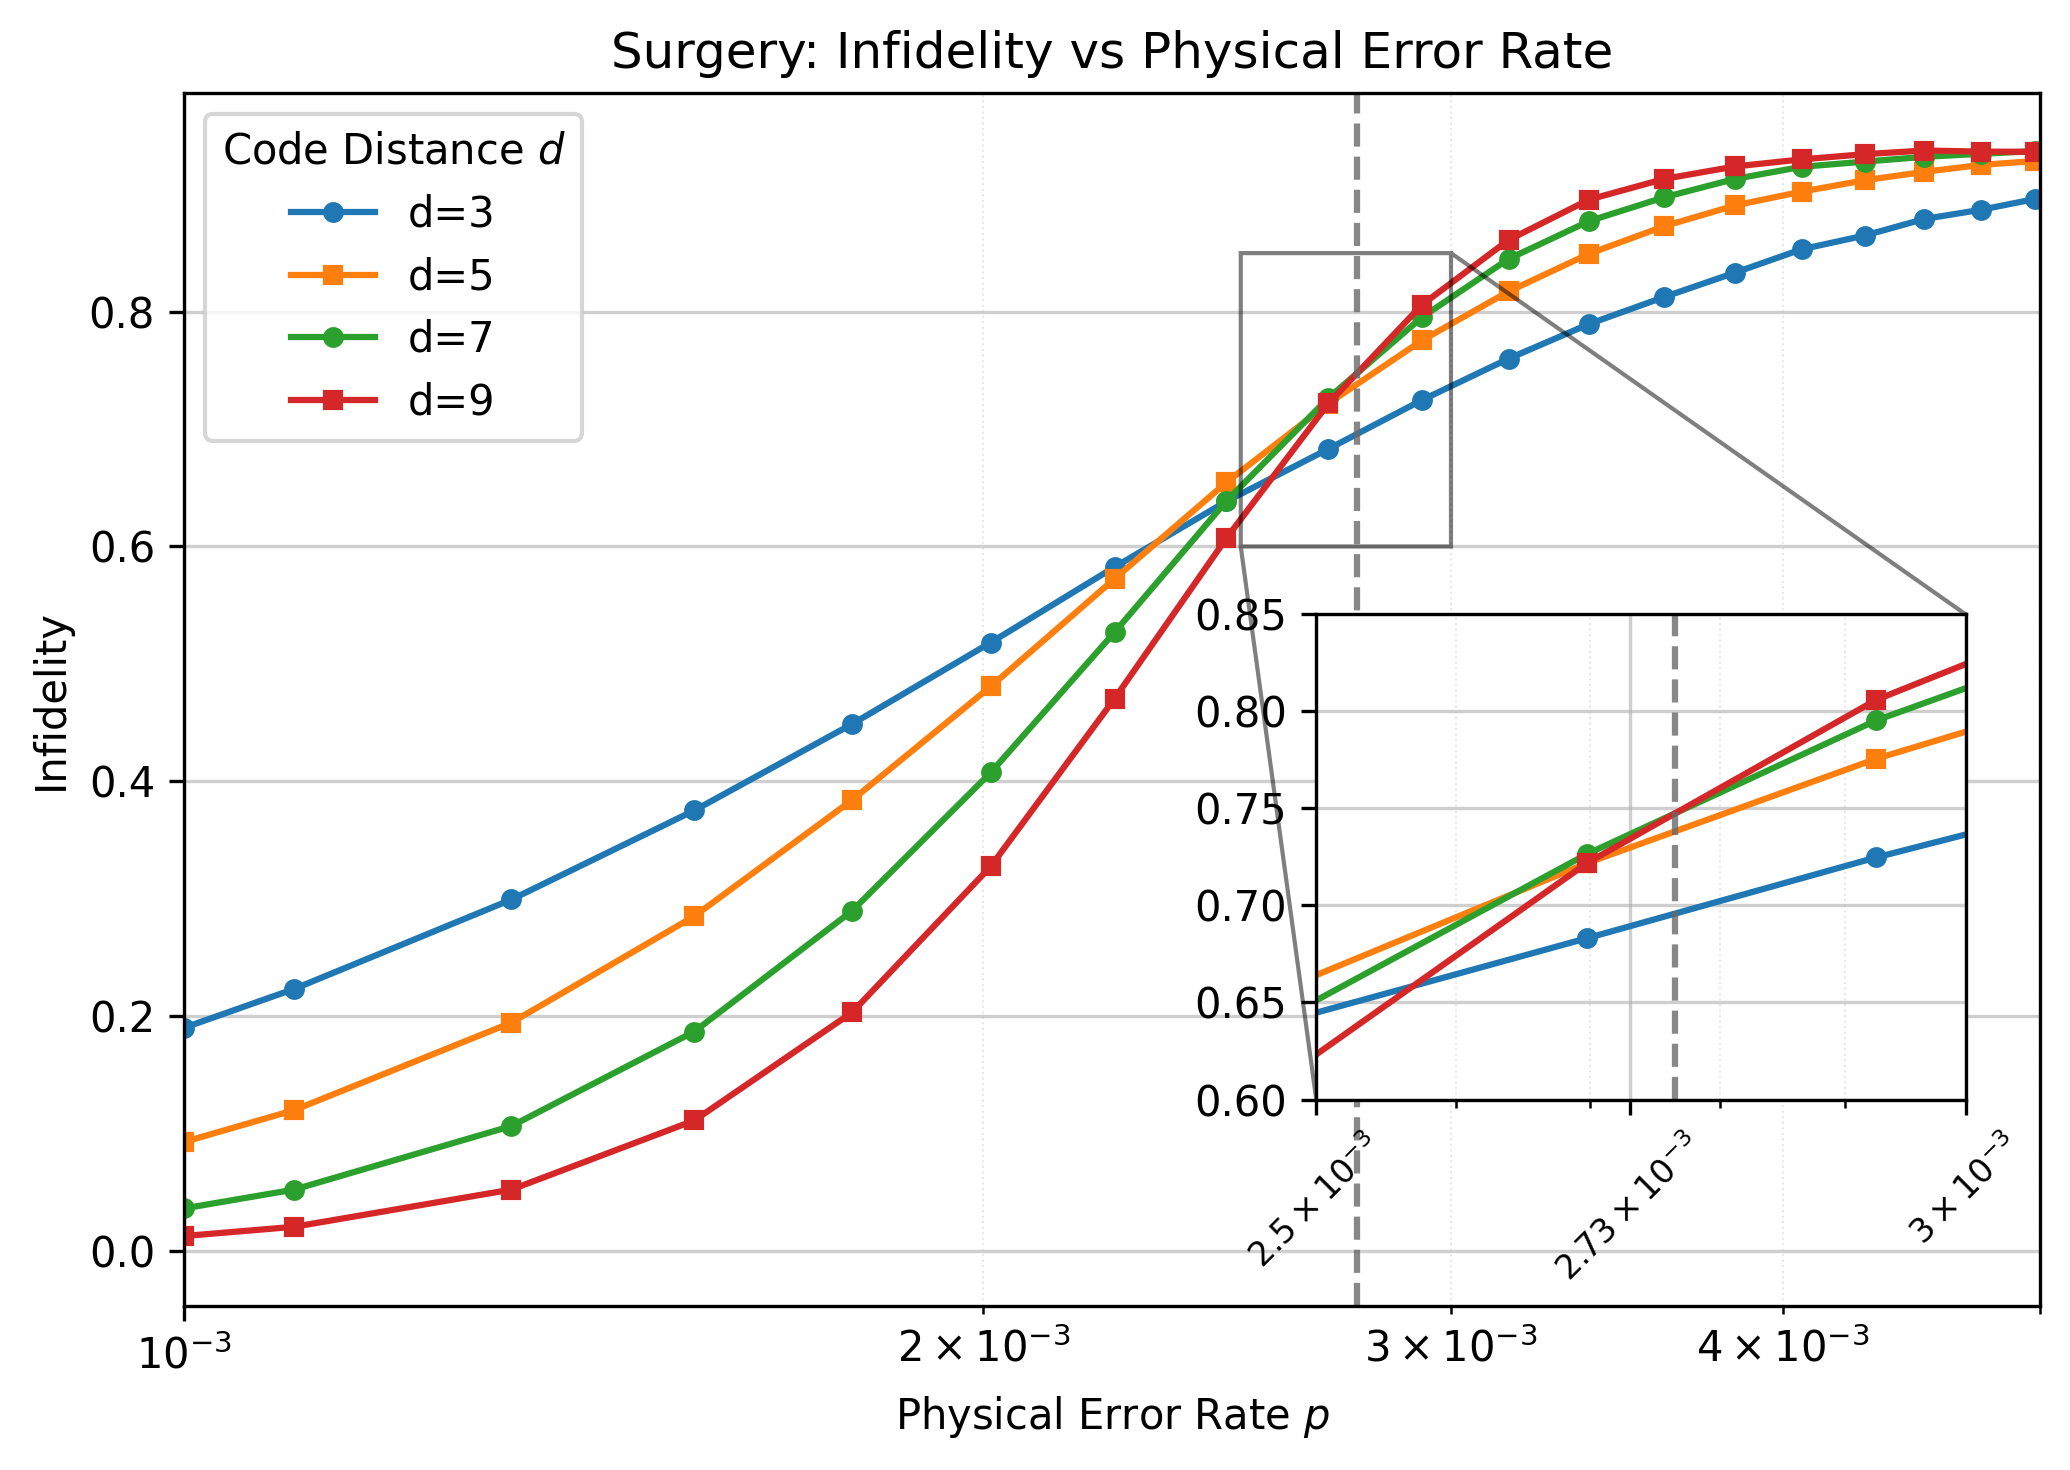

In [32]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Define the threshold
THRESHOLD_P = 2.765e-3

# Setup the main plot
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Plot on the main axis
ax.plot(probs, infidelities_d3, 'o-', markersize=4, label='d=3')
ax.plot(probs, infidelities_d5, 's-', markersize=4, label='d=5')
ax.plot(probs, infidelities_d7, 'o-', markersize=4, label='d=7')
ax.plot(probs, infidelities_d9, 's-', markersize=4, label='d=9')

# Main Axis Formatting
ax.set_xlim(1e-3, 5e-3)
ax.set_xscale('log')
ax.set_title('Surgery: Infidelity vs Physical Error Rate')
ax.set_xlabel('Physical Error Rate $p$')
ax.set_ylabel('Infidelity')

ax.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add vertical line to the main plot
ax.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Legend placed in the lower right
ax.legend(title="Code Distance $d$", loc='upper left')

# ==========================================
# Inset Plot for the Threshold Zoom
# ==========================================
# Placed in the upper left [x0, y0, width, height]
axins = ax.inset_axes([0.61, 0.17, 0.35, 0.4])

# Re-plot the exact same lines onto the inset axes
axins.plot(probs, infidelities_d3, 'o-', markersize=4)
axins.plot(probs, infidelities_d5, 's-', markersize=4)
axins.plot(probs, infidelities_d7, 'o-', markersize=4)
axins.plot(probs, infidelities_d9, 's-', markersize=4)

# Formatting the inset
axins.set_xscale('log')

# Zoomed limits for x (centered around the 2.73e-3 threshold)
axins.set_xlim(2.5e-3, 3.0e-3)
axins.set_ylim(0.6, 0.85)

# --- FORMATTING FIX FOR SCIENTIFIC NOTATION ---
# 1. Set specific tick marks so they don't crowd
axins.set_xticks([2.5e-3, 2.73e-3, 3.0e-3])

# 2. Force the standard Matplotlib scientific math-text style
def sci_format(x, pos):
    return f"${x / 1e-3:g} \\times 10^{{-3}}$"

axins.xaxis.set_major_formatter(FuncFormatter(sci_format))
axins.xaxis.set_minor_formatter(plt.NullFormatter())

# 3. Rotate labels 45 degrees so they fit cleanly
axins.tick_params(axis='x', rotation=45, labelsize=8)
# ----------------------------------------------

axins.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.6)
axins.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.3)

# Add the vertical line to the inset plot
axins.axvline(x=THRESHOLD_P, color='dimgray', linestyle='--', alpha=0.8)

# Clean up inset labels
axins.set_xlabel('')
axins.set_ylabel('')

# Automatically draw a box and connecting lines
ax.indicate_inset_zoom(axins, edgecolor="black")
# ==========================================

# Final output
fig.set_dpi(300)
plt.tight_layout()

# Save plot as PDF
plt.savefig("../plots/Surgery_infidelity_vs_physical_error_rate.pdf", bbox_inches='tight')

# Show the plot
plt.show()